Generative Pre-trained Transformer

In [35]:
import tiktoken
import torch
import torch.nn as nn
import urllib.request
import matplotlib.pyplot as plt
import torch.nn.functional as F

In [21]:
# data_path = "/home/bukunmi/ml-journey/datasets/shakespearesonnet.txt"

# with open(data_path, "r", encoding="utf-8") as f:
#     raw_text = f.read()

In [22]:
url = "https://www.gutenberg.org/cache/epub/1041/pg1041.txt"
print("Downloading Shakespeare's Sonnets...")
try:
    with urllib.request.urlopen(url) as response:
        raw_text = response.read().decode('utf-8')
    
    print(f"Successfully downloaded! Total length: {len(raw_text)} characters.\n")
    
    start_marker = "THE SONNETS"
    start_idx = raw_text.find(start_marker)
    end_marker = "*** END OF THE PROJECT GUTENBERG EBOOK"
    end_idx = raw_text.find(end_marker)

    if start_idx != -1 and end_idx != -1:
        raw_text = raw_text[start_idx:end_idx].strip()
    print("--- FIRST 3 SONNET LINES ---")
    lines = raw_text.split('\n')
    for line in lines[40:55]:
        print(line)
except Exception as e:
    print(f"An error occurred: {e}")


Successfully downloaded! Total length: 118546 characters.

--- FIRST 3 SONNET LINES ---

III

Look in thy glass and tell the face thou viewest
Now is the time that face should form another;
Whose fresh repair if now thou not renewest,
Thou dost beguile the world, unbless some mother.
For where is she so fair whose unear’d womb
Disdains the tillage of thy husbandry?
Or who is he so fond will be the tomb,
Of his self-love to stop posterity?
Thou art thy mother’s glass and she in thee
Calls back the lovely April of her prime;
So thou through windows of thine age shalt see,
Despite of wrinkles this thy golden time.


In [23]:
corpus = raw_text[:150].strip()
print(f"Sample Corpus Details:\n{"="*30}\n{corpus}\n{"="*30}")

Sample Corpus Details:
THE SONNETS

by William Shakespeare




I

From fairest creatures we desire increase,
That thereby beauty’s rose might never die,
But as th


In [24]:
enc = tiktoken.encoding_for_model("gpt-4o")
token_ids = enc.encode(raw_text)
vocab_size = enc.max_token_value + 1

In [25]:
data_tensor = torch.tensor(token_ids, dtype=torch.long)

Batching

In [43]:
block_size = 128
batch_size = 16

def get_batch(device):
    ix = torch.randint(0, len(data_tensor) - block_size, (batch_size,))
    x = torch.stack([data_tensor[i:i + block_size] for i in ix])
    y = torch.stack([data_tensor[i + 1:i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)

Embeddings

In [44]:
embedding_dim = 64

Attention

In [45]:
class CausalAttention(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.q = nn.Linear(dim, dim, bias=False)
        self.k = nn.Linear(dim, dim, bias=False)
        self.v = nn.Linear(dim, dim, bias=False)
    
    def forward(self, x):
        B, T, C = x.shape
        Q = self.q(x)
        K = self.k(x)
        V = self.v(x)

        scores = (Q @ K.transpose(-2, -1)) * (C ** -0.5)
        mask = torch.tril(torch.ones(T, T, device=x.device)).view(1, T, T)

        scores = scores.masked_fill(mask == 0, float('-inf'))
        probs = F.softmax(scores, dim=-1)
        return probs @ V

Transformer

In [46]:
class TransformerBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.ln1 = nn.LayerNorm(dim)
        self.attn = CausalAttention(dim)
        self.ln2 = nn.LayerNorm(dim)
        self.ffn = nn.Sequential(
            nn.Linear(dim, 4 * dim),
            nn.ReLU(),
            nn.Linear(4 * dim, dim)
        )
    
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ffn(self.ln2(x))
        return x

Language head

In [47]:
class TinyGPT(nn.Module):
    def __init__(self, vocab_size, dim, max_len):
        super().__init__()
        self.vocab_size = vocab_size
        self.token_emb = nn.Embedding(vocab_size, dim)
        self.pos_emb = nn.Embedding(max_len, dim)
        self.block = TransformerBlock(dim)
        self.ln_f = nn.LayerNorm(dim)
        self.lm_head = nn.Linear(dim, vocab_size)
    
    def forward(self, idx, targets=None):
        B, T = idx.shape

        tok_vectors = self.token_emb(idx)
        pos_vectors = self.pos_emb(torch.arange(T, device=idx.device))
        x = tok_vectors + pos_vectors

        x = self.block(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.reshape(-1, self.vocab_size), targets.reshape(-1))
        
        return logits, loss

Training

In [48]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TinyGPT(vocab_size, embedding_dim, block_size + 1).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
max_iters = 3000
loss_history = {}

for step in range(max_iters):
    x_batch, y_batch = get_batch(device)
    logits, loss = model(x_batch, y_batch)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 25 == 0:
        print(f"Step {step:3d} | Cross-Entropy Loss: {loss.item():.5f}")
        loss_history[step] = loss.item()

Step   0 | Cross-Entropy Loss: 12.37279
Step  25 | Cross-Entropy Loss: 10.37567
Step  50 | Cross-Entropy Loss: 7.34418
Step  75 | Cross-Entropy Loss: 6.54255
Step 100 | Cross-Entropy Loss: 6.46611
Step 125 | Cross-Entropy Loss: 6.51954
Step 150 | Cross-Entropy Loss: 6.53979
Step 175 | Cross-Entropy Loss: 6.36746
Step 200 | Cross-Entropy Loss: 6.18553
Step 225 | Cross-Entropy Loss: 6.11580
Step 250 | Cross-Entropy Loss: 6.03648
Step 275 | Cross-Entropy Loss: 6.00109
Step 300 | Cross-Entropy Loss: 5.83557
Step 325 | Cross-Entropy Loss: 5.74495
Step 350 | Cross-Entropy Loss: 5.67025
Step 375 | Cross-Entropy Loss: 5.48672
Step 400 | Cross-Entropy Loss: 5.41254
Step 425 | Cross-Entropy Loss: 5.48867
Step 450 | Cross-Entropy Loss: 5.16662
Step 475 | Cross-Entropy Loss: 5.08173
Step 500 | Cross-Entropy Loss: 4.99982
Step 525 | Cross-Entropy Loss: 4.99115
Step 550 | Cross-Entropy Loss: 4.74504
Step 575 | Cross-Entropy Loss: 4.66436
Step 600 | Cross-Entropy Loss: 4.51771
Step 625 | Cross-Entrop

I got a final training loss of 1.68765

Text(0.5, 1.0, 'Training Loss')

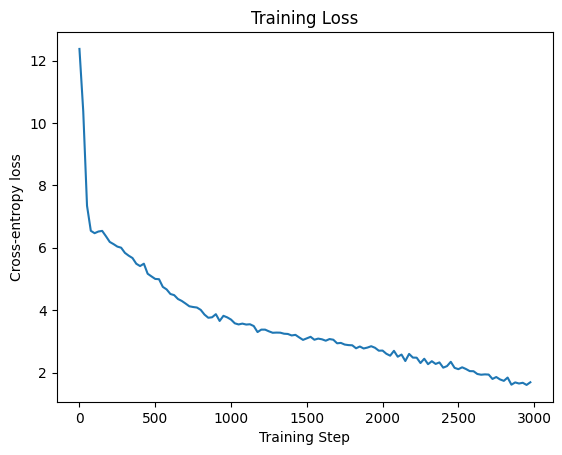

In [50]:
steps = [step for step in loss_history.keys()]
losses = list(loss_history.values())

plt.plot(steps, losses)
plt.xlabel("Training Step")
plt.ylabel("Cross-entropy loss")
plt.title("Training Loss")

In [53]:
model.eval()
with torch.no_grad():
    seed_token = token_ids[0]
    generated_indices = [seed_token]
    max_new_tokens = 100

    for _ in range(max_new_tokens):
        context = generated_indices[-block_size:]
        input_tensor = torch.tensor([context], dtype=torch.long, device=device)
        logits, _ = model(input_tensor)

        next_token = torch.argmax(logits[0, -1, :]).item()
        generated_indices.append(next_token)
    
    print("="*30, "\n", "Original Corpus", "\n", "="*30, "\n", corpus, "\n", "="*30, "\n")
    print("="*30, "\n", "Generated Corpus", "\n", "="*30, "\n", enc.decode(generated_indices), "\n", "="*30)

 Original Corpus 
 THE SONNETS

by William Shakespeare




I

From fairest creatures we desire increase,
That thereby beauty’s rose might never die,
But as th 

 Generated Corpus 
 THE shows’d, to the world, being made me young with a hell:
When I love thee,
And I fair no leisure taken,
And I sufferance, whereon my transfix the world are but as the world doth my judgement knew no reason why
The statute of heaven’s woe;
Give salve, nor the old,
Unless my rude, or changes right, or eye shall I as the sea and to my rude, or eye, or eye saith true,
And by 


Prompted next-token generation

In [54]:
def generate_text(model, prompt, max_new_tokens=20):
    model.eval()
    generated_indices = enc.encode(prompt)

    with torch.no_grad():
        for _ in range(max_new_tokens):
            context = generated_indices[-block_size:]
            input_tensor = torch.tensor([context], dtype=torch.long, device=device)
            logits, _ = model(input_tensor)
            next_token_logits = logits[0, -1, :]
            next_token = torch.argmax(next_token_logits).item()
            generated_indices.append(next_token)
    return enc.decode(generated_indices)


In [59]:
prompt = "Time and tide"
print(generate_text(model, prompt, max_new_tokens=20))

Time and tide strong infection meet,
One grew a tresses of you were but one,
    But you were some
